In [1]:
import os
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import re
import openpyxl
import numpy as np

In [2]:
folder=r'C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\Import files\JNP\JNP_Extract'
OFolder=r'C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\Import files'

In [3]:
file_list=[]
for (root, dirs, file) in os.walk(folder):
    for f in file:
        if ('.xlsx') in f:

                    file_list.append(f)
file_list

['Articles (1).xlsx',
 'Articles (10).xlsx',
 'Articles (11).xlsx',
 'Articles (12).xlsx',
 'Articles (13).xlsx',
 'Articles (14).xlsx',
 'Articles (15).xlsx',
 'Articles (16).xlsx',
 'Articles (17).xlsx',
 'Articles (18).xlsx',
 'Articles (19).xlsx',
 'Articles (2).xlsx',
 'Articles (20).xlsx',
 'Articles (21).xlsx',
 'Articles (22).xlsx',
 'Articles (23).xlsx',
 'Articles (24).xlsx',
 'Articles (25).xlsx',
 'Articles (26).xlsx',
 'Articles (27).xlsx',
 'Articles (28).xlsx',
 'Articles (29).xlsx',
 'Articles (3).xlsx',
 'Articles (30).xlsx',
 'Articles (31).xlsx',
 'Articles (32).xlsx',
 'Articles (33).xlsx',
 'Articles (34).xlsx',
 'Articles (35).xlsx',
 'Articles (36).xlsx',
 'Articles (37).xlsx',
 'Articles (38).xlsx',
 'Articles (39).xlsx',
 'Articles (4).xlsx',
 'Articles (40).xlsx',
 'Articles (41).xlsx',
 'Articles (42).xlsx',
 'Articles (43).xlsx',
 'Articles (44).xlsx',
 'Articles (45).xlsx',
 'Articles (46).xlsx',
 'Articles (47).xlsx',
 'Articles (48).xlsx',
 'Articles (49)

In [4]:
file_link=[]

for i in range(len(file_list)):
     for r,d,f in os.walk(folder):
          for files in f:
               if files == file_list[i]:
                    file_link.append(os.path.join(r,files))

In [5]:
len(file_link)

66

In [6]:
file_link[1]

'C:\\Users\\vikram.vadhirajan\\OneDrive - Trico\\Documents - Product Support India Romania\\Catalog\\Score card\\Standard\\Import files\\JNP\\JNP_Extract\\Articles (10).xlsx'

In [7]:
cols=["Article Number",
"Brand",
"Region",
"Product Group",
"Product Group Overrides",
"Product Line",
"Publishing Countries",
"Article Status Code",
"Article Status Description",
"Children article numbers",
"Attribute",
"Value",
]
df_s = pd.DataFrame(columns=cols)
df_s


,Article Number,Brand,Region,Product Group,Product Group Overrides,Product Line,Publishing Countries,Article Status Code,Article Status Description,Children article numbers,Attribute,Value


In [8]:
repl='''C:\\Users\\Vikram.Vadhirajan\\OneDrive - Trico\\Documents - Product Support India Romania\\Catalog\\Score card\\Standard\\GM_Update\\'''
IDS=["Article Number",
"Brand",
"Region",
"Product Group",
"Product Group Overrides",
"Product Line",
"Publishing Countries",
"Article Status Code",
"Article Status Description"]

In [9]:
for i in range(len(file_link)):
    workbook=openpyxl.load_workbook(file_link[i])
    print(file_link[i])
    df=pd.read_excel(file_link[i],sheet_name="article-export")
    df=pd.melt(df,id_vars=IDS,var_name="Attribute",value_name="Value").reset_index(drop=True)
    df_s=pd.concat([df_s,df])   


C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\Import files\JNP\JNP_Extract\Articles (1).xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\Import files\JNP\JNP_Extract\Articles (10).xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\Import files\JNP\JNP_Extract\Articles (11).xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\Import files\JNP\JNP_Extract\Articles (12).xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\Import files\JNP\JNP_Extract\Articles (13).xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\Import files\JNP\JNP_Extract\Articles (14).xlsx
C:\Users\vikram.vadhirajan\On

<Axes: >

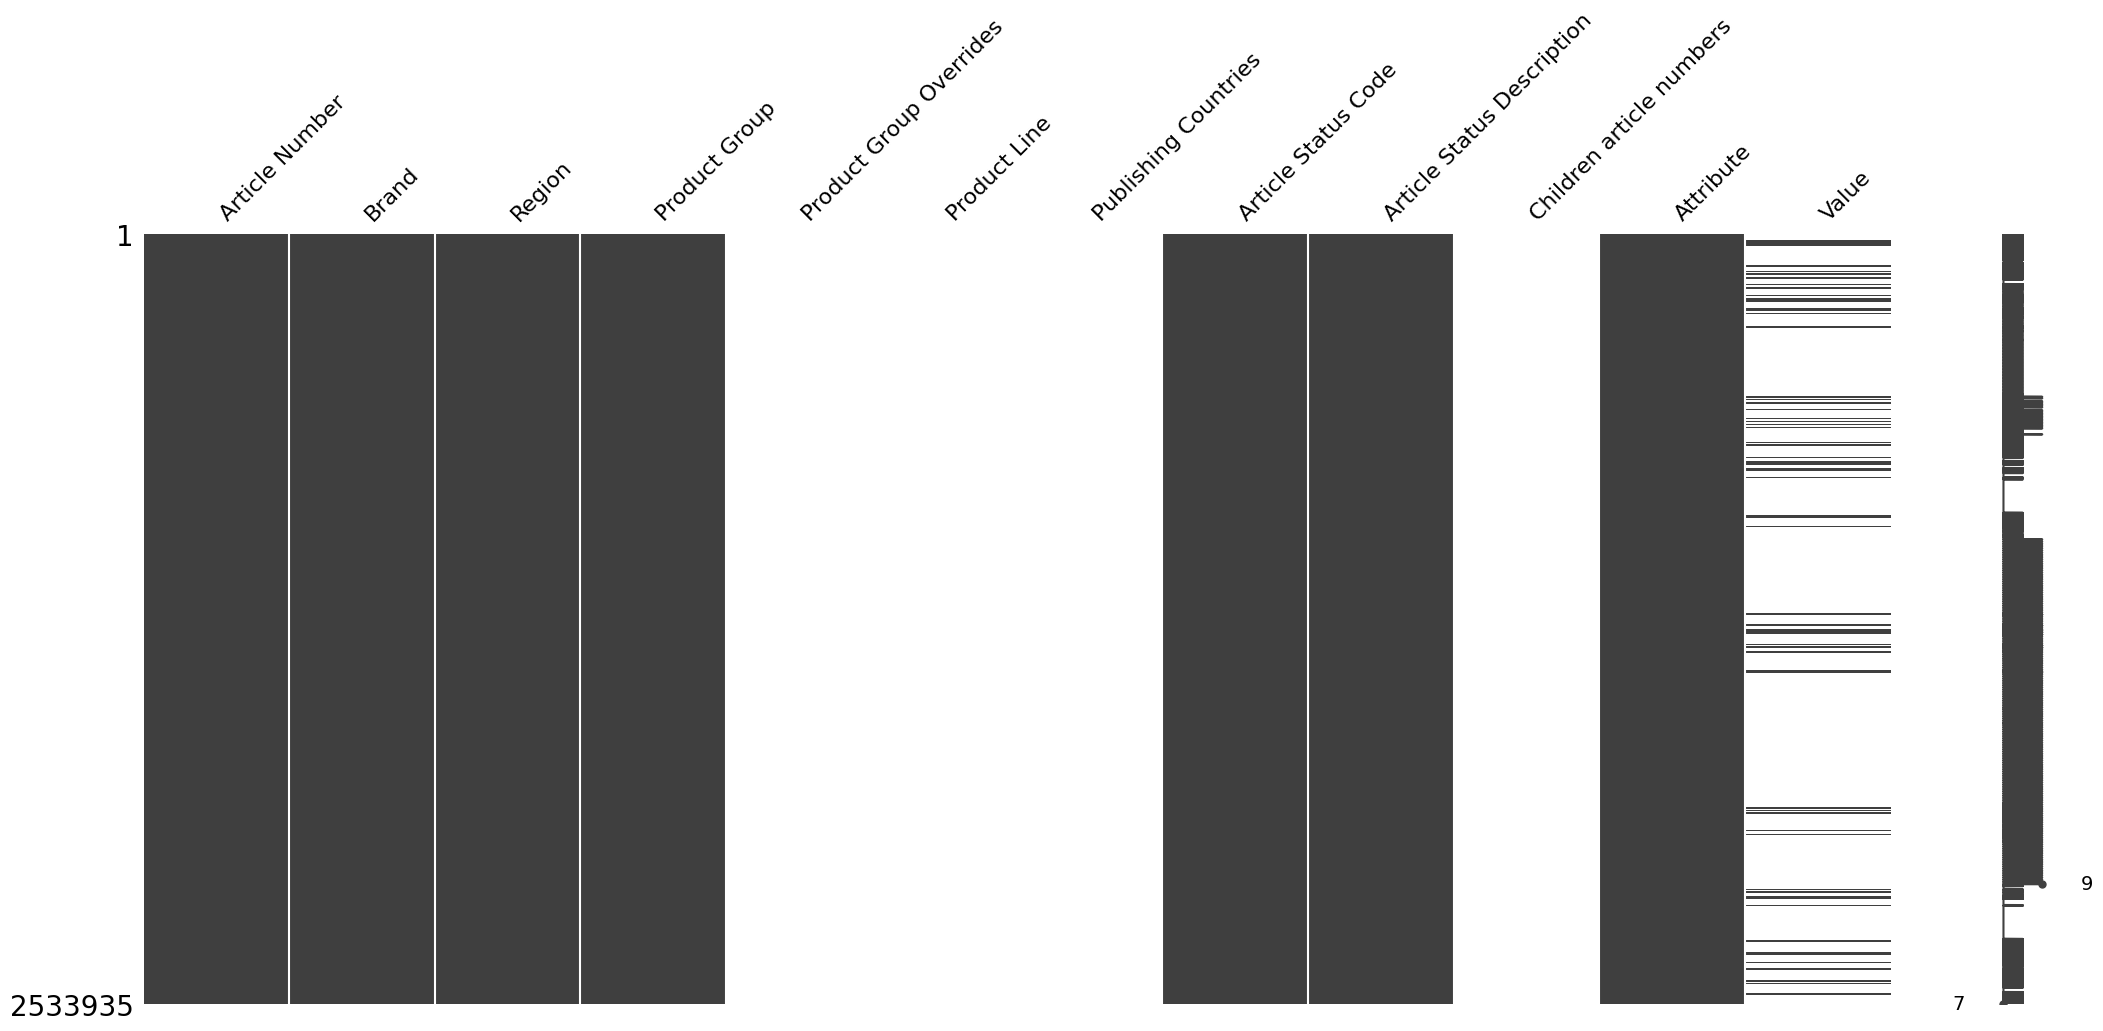

In [10]:
import missingno as msno 
msno.matrix(df_s)

In [11]:
df_Match=df_s
df_Match.rename(columns={"Article Number":"PartNumber","Product Group":"PartTerminologyName",'Attribute':'PAName'},inplace=True)
df_Match=df_Match[["Brand",'PartTerminologyName',"PartNumber","PAName","Value"]]

In [12]:
df_Match['Brand']="BPI"
df_Match

,Brand,PartTerminologyName,PartNumber,PAName,Value
0,BPI,Wheel Hub Washer,A99000,Finish,Silver
1,BPI,Wheel Hub Washer,A99000,Inside Diameter (in),0.591
2,BPI,Wheel Hub Washer,A99000,Inside Diameter (mm),15
3,BPI,Wheel Hub Washer,A99000,Outside Diameter (in),1.181
4,BPI,Wheel Hub Washer,A99000,Outside Diameter (mm),30
...,...,...,...,...,...
3099,BPI,Wheel Lug Stud,9528B,Wheel Stud Thread Pitch (mm),NaN
3100,BPI,Wheel Lug Stud,9530B,Wheel Stud Thread Pitch (mm),NaN
3101,BPI,Wheel Lug Stud,9550B,Wheel Stud Thread Pitch (mm),NaN
3102,BPI,Wheel Lug Stud,9585B,Wheel Stud Thread Pitch (mm),NaN


In [13]:
df_Match['PAName']=np.where(df_Match['PAName'].str.contains('(in)'), df_Match['PAName'].str.replace('(in)',""), df_Match['PAName'])
df_Match['PAName']=np.where(df_Match['PAName'].str.contains('(mm)'), df_Match['PAName'].str.replace('(mm)',""), df_Match['PAName'])
df_Match['PAName']=np.where(df_Match['PAName'].str.contains('(cm)'), df_Match['PAName'].str.replace('(cm)',""), df_Match['PAName'])

In [14]:
# unique_items_with_parentheses = df_Match[df_Match['PAName'].str.contains(r'\(', na=False)]['PAName'].unique()
# unique_items_with_parentheses

In [15]:
df_Match

,Brand,PartTerminologyName,PartNumber,PAName,Value
0,BPI,Wheel Hub Washer,A99000,Finish,Silver
1,BPI,Wheel Hub Washer,A99000,Inside Diameter,0.591
2,BPI,Wheel Hub Washer,A99000,Inside Diameter,15
3,BPI,Wheel Hub Washer,A99000,Outside Diameter,1.181
4,BPI,Wheel Hub Washer,A99000,Outside Diameter,30
...,...,...,...,...,...
3099,BPI,Wheel Lug Stud,9528B,Wheel Stud Thread Pitch,NaN
3100,BPI,Wheel Lug Stud,9530B,Wheel Stud Thread Pitch,NaN
3101,BPI,Wheel Lug Stud,9550B,Wheel Stud Thread Pitch,NaN
3102,BPI,Wheel Lug Stud,9585B,Wheel Stud Thread Pitch,NaN


In [16]:
df_Attributes=df_Match[['Brand', 'PartTerminologyName',  'PAName']].drop_duplicates().reset_index(drop=True)

In [17]:
chunk_size=1000000
# Create a list of DataFrames by splitting the original DataFrame
df_chunks = [df_Match.iloc[i:i + chunk_size] for i in range(0, len(df_Match), chunk_size)]

In [18]:
with pd.ExcelWriter(OFolder+'\\'+'BPI_Attribute_List.xlsx') as writer:  # doctest: +SKIP
    for i, chunk in enumerate(df_chunks):
        sheet_name = f"Chunk_{i+1}"  # Naming each sheet dynamically
        chunk.to_excel(writer, sheet_name=sheet_name, index=False)
    df_Attributes.to_excel(writer,index=False, sheet_name='FBG_Attributes')

## Misc Codes

In [46]:
df_Final.to_csv('Combined_Data.csv', index=False)

In [47]:
df_articlemap=df_Final[['Article Number','Children article numbers']]
df_articlemap=df_articlemap.drop_duplicates().reset_index(drop=True)

In [48]:
df_articlemap['Children article numbers'] = df_articlemap['Children article numbers'].str.split(',')
df_articlemap=df_articlemap.explode('Children article numbers')
df_articlemap=df_articlemap.reset_index(drop=True)

In [49]:
df_articlemap.to_csv('BaseChildMap.csv', index=False)